# Test lc_run_through Extension

This notebook tests that the lc_run_through JupyterLab extension is properly installed and enabled.
- Verify run_through icons are displayed properly

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmptfs9hkjs


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251224-150212',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmptsjobl31')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766556132.8687758 seconds


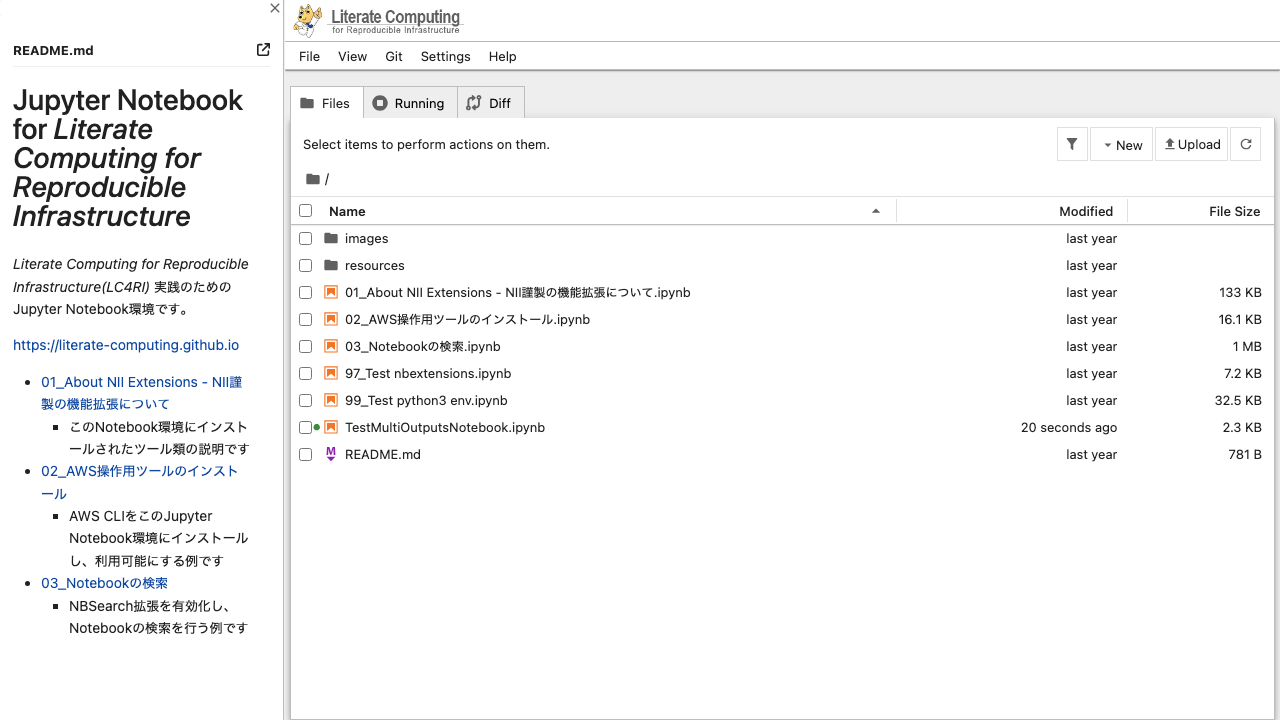

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Remove existing test notebook if it exists

Start epoch: 1766556137.016774 seconds
No existing test notebook to remove


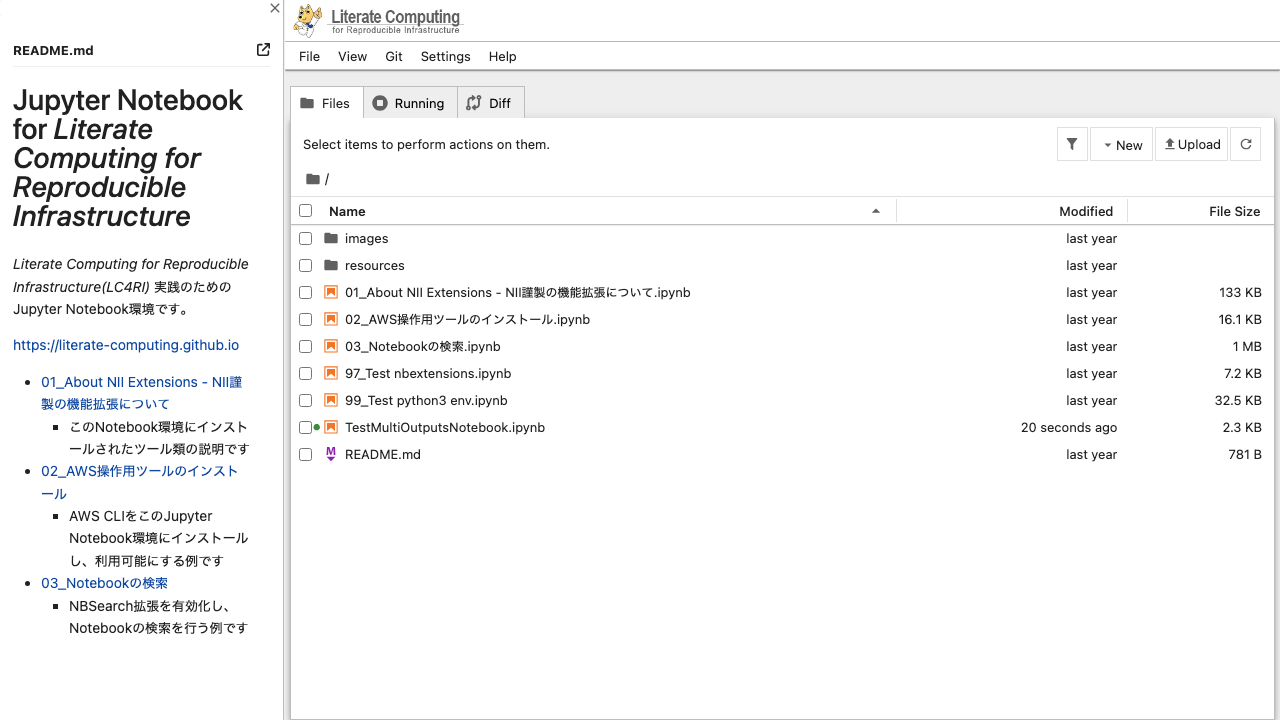

In [6]:
test_filename = "TestRunThroughNotebook.ipynb"
async def _step_remove_existing_notebook(page):
    deleted = await delete_file(page, test_filename, timeout=transition_timeout)
    if deleted:
        print("✓ Removed existing test notebook")
    else:
        print("No existing test notebook to remove")

await run_pw(_step_remove_existing_notebook)

## Create a new notebook for testing run_through

Start epoch: 1766556137.148407 seconds


✓ New notebook created


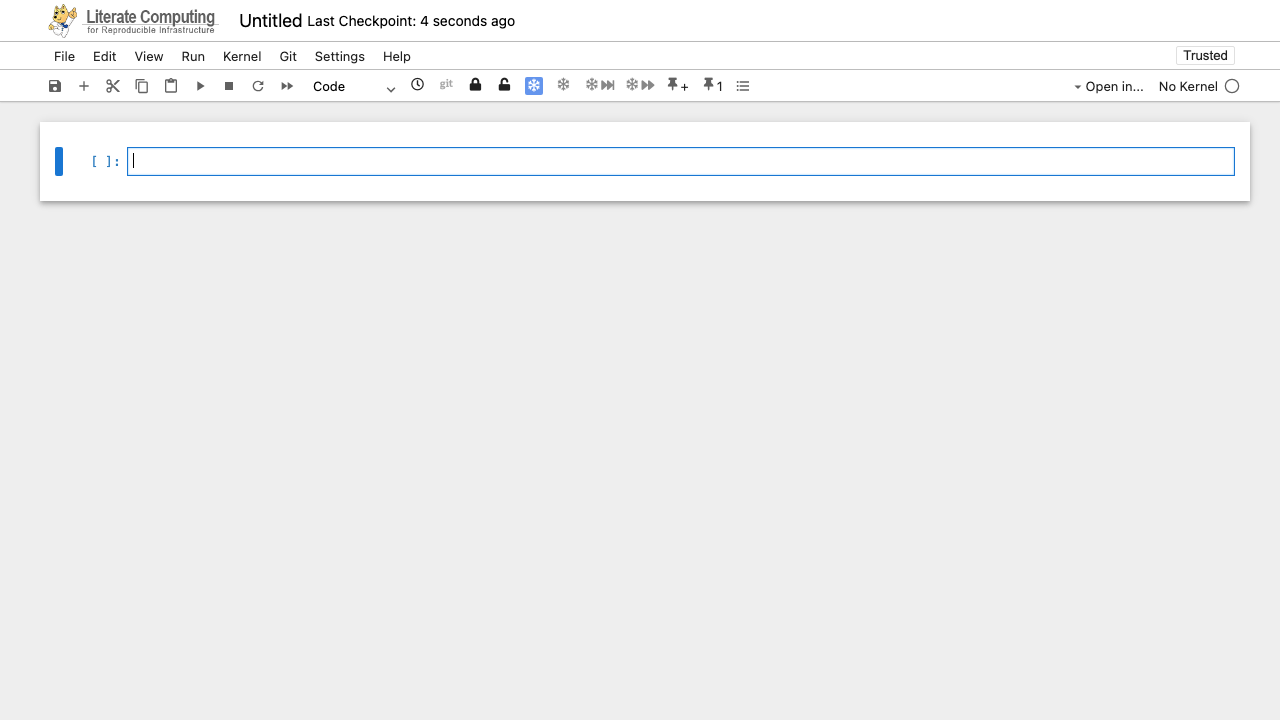

In [7]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Rename and save the notebook

Start epoch: 1766556141.6260638 seconds


✓ Notebook renamed and saved


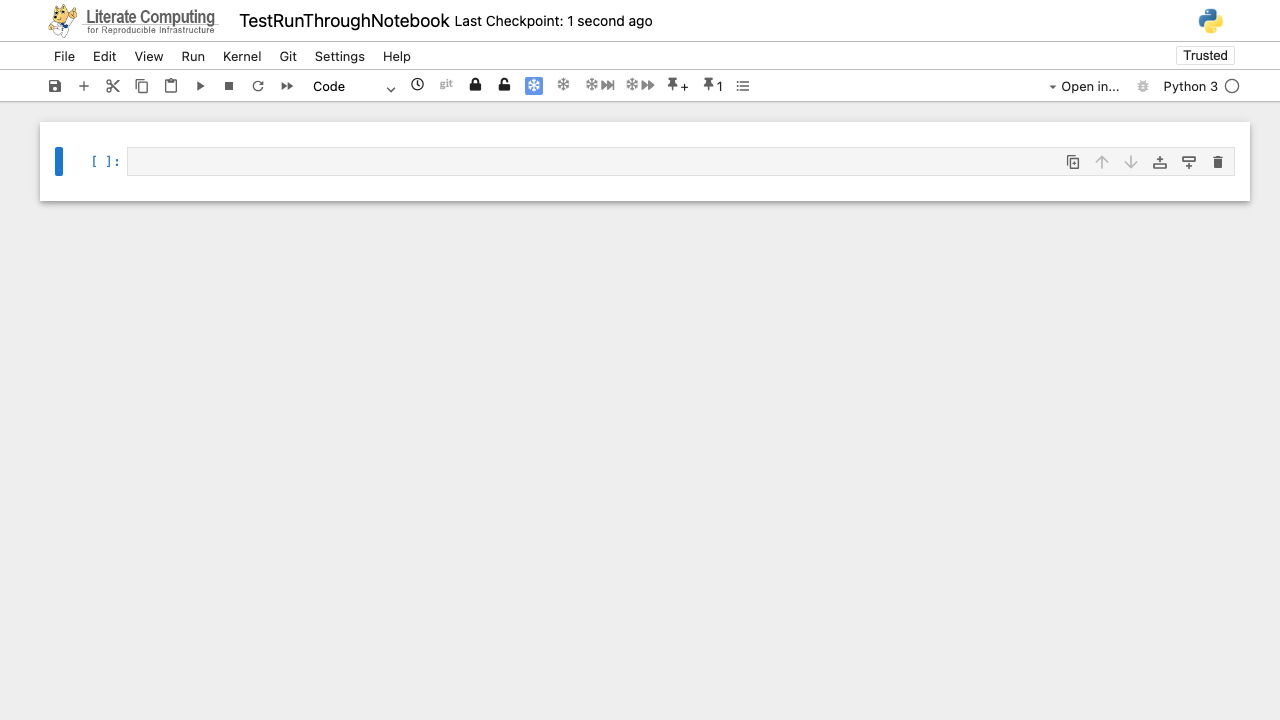

In [8]:
async def _step_rename_and_save(page):
    # Rename the notebook
    await rename_notebook(page, test_filename, timeout=transition_timeout)
    
    # Save the notebook
    await save_notebook(page)
    
    print("✓ Notebook renamed and saved")

await run_pw(_step_rename_and_save)

## Create test cells and run all

Start epoch: 1766556143.5038369 seconds


✓ Created 3 test cells


✓ All cells executed


✓ Non-executed cell added


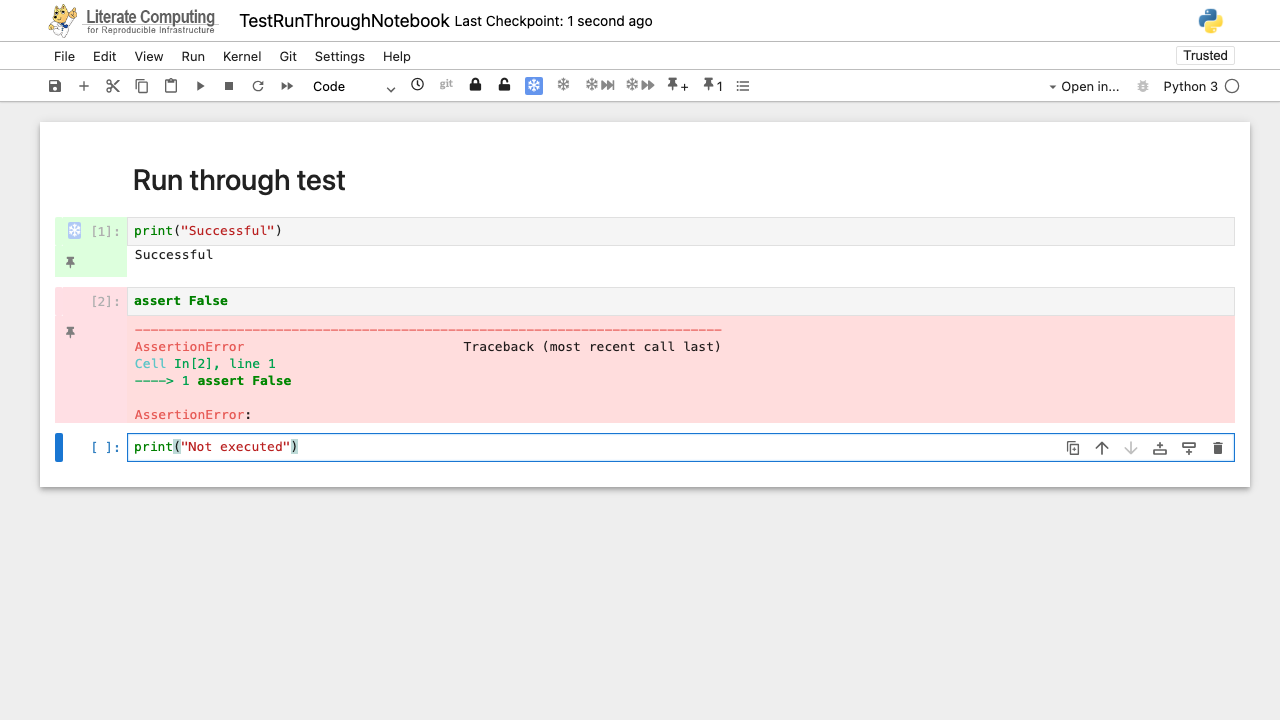

In [9]:
async def _step_create_and_run_cells(page):
    # Create test cells
    await set_cell(page, 0, "markdown", "# Run through test", timeout=transition_timeout)
    await add_cell(page, "code", 'print("Successful")', timeout=transition_timeout)
    await add_cell(page, "code", "assert False", timeout=transition_timeout)
    print("✓ Created 3 test cells")
    
    # Run all cells
    await run(page, timeout=transition_timeout)
    print("✓ All cells executed")

    # Add non-executed cell
    await add_cell(page, "code", 'print("Not executed")', timeout=transition_timeout)
    print("✓ Non-executed cell added")

await run_pw(_step_create_and_run_cells)

## Verify run_through icons are displayed properly

Start epoch: 1766556152.644295 seconds


✓ Found 3 code result widgets
✓ Icon 1 is success
✓ Icon 2 is error
✓ Icon 3 has no success/error class


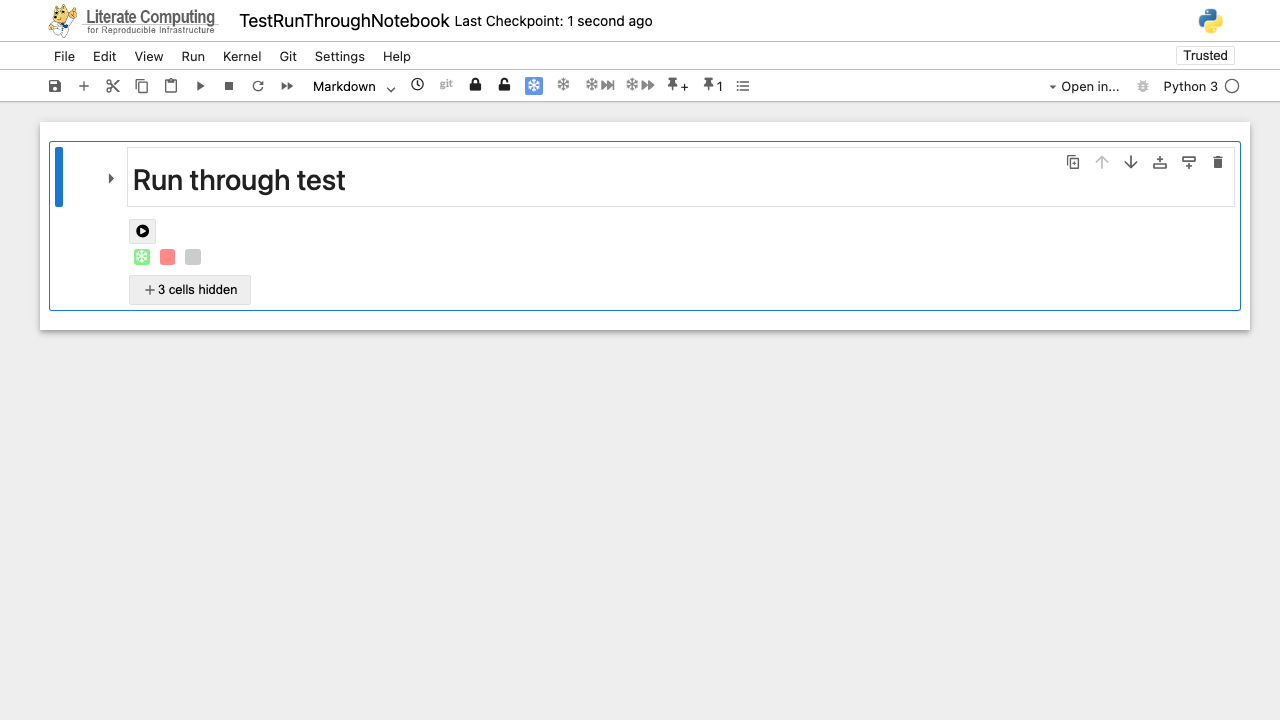

In [10]:
async def _step_verify_run_through_icons(page):
    # Click Collapse Heading Button on the first cell
    await select_cell(page, 0, timeout=transition_timeout)
    cell = await get_cell(page, 0, timeout=transition_timeout)

    collapse_heading_button = cell.locator('button.jp-collapseHeadingButton')
    await expect(collapse_heading_button).to_be_visible(timeout=transition_timeout)
    await collapse_heading_button.click()

    # Get Run through result icons
    section_cells = page.locator('.run-through-section-cells')
    results = section_cells.locator('.run-through-code-result')
    await expect(results).to_have_count(3)
    print("✓ Found 3 code result widgets")

    # icon1 (Success)
    class_name = await results.nth(0).get_attribute('class')
    assert 'run-through-code-result__success' in class_name
    print("✓ Icon 1 is success")

    # icon2 (Error)
    class_name = await results.nth(1).get_attribute('class')
    assert 'run-through-code-result__error' in class_name
    print("✓ Icon 2 is error")

    # icon3 (Not executed - no success or error class)
    class_name = await results.nth(2).get_attribute('class')
    assert 'run-through-code-result__success' not in class_name
    assert 'run-through-code-result__error' not in class_name
    print("✓ Icon 3 has no success/error class")

await run_pw(_step_verify_run_through_icons)

## Save the notebook

Start epoch: 1766556152.9258912 seconds


✓ Notebook saved


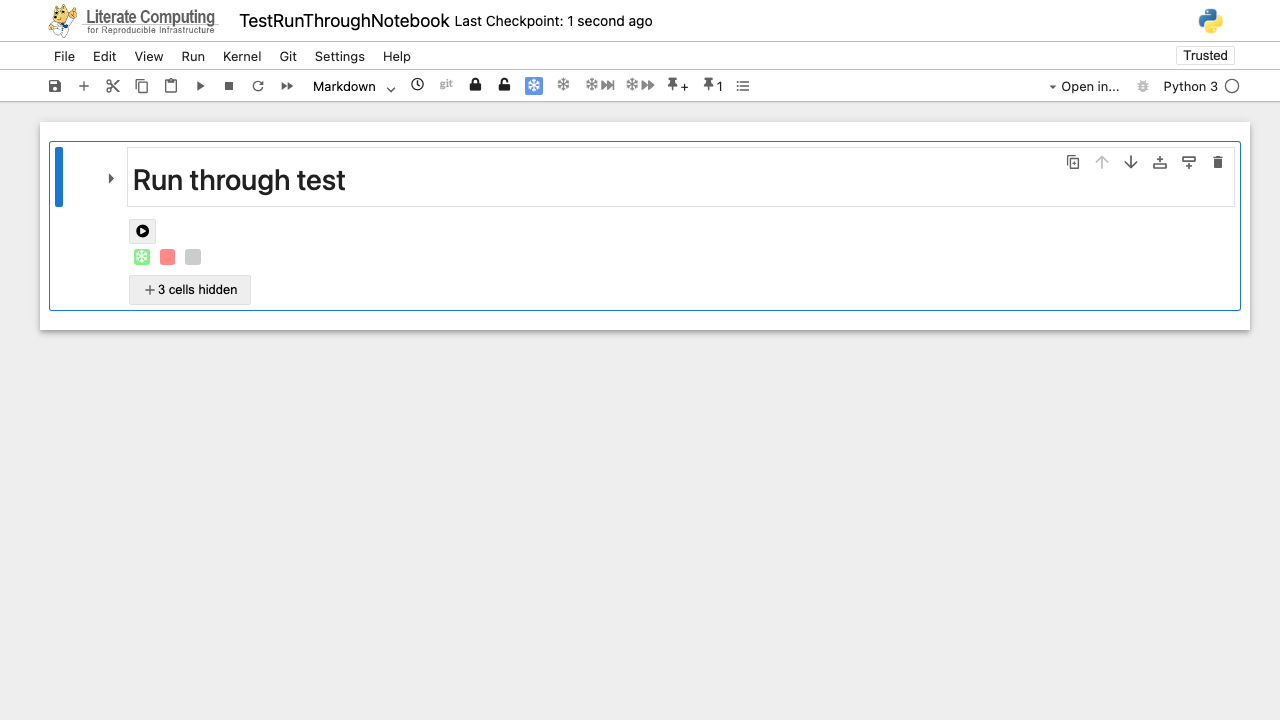

In [11]:
async def _step_save_notebook(page):
    await save_notebook(page)
    print("✓ Notebook saved")

await run_pw(_step_save_notebook)

## Cleanup

In [ ]:
await finish_pw_context()

In [13]:
!rm -rf {work_dir}